# SCADA Functionality Test Visualiser

**Author:** Erick Chauke

SCADA stands for Supervisory Control and Data Acquisition, the system that runs a power plant and logs its measurements every second. Each grid-code functionality test leaves one of these logger spreadsheets, and today every one is checked by eye against the acceptance procedure. This notebook starts to automate that. Drop a test export into `data/`, run the notebook, and it parses the channels, compares the measured values against their setpoints and control modes, and plots whether the plant met each part of the procedure. The procedure is the SCADA Functionality Test Record (Rev 3) from NCSS, the National Control System Support group of the grid operator [1]. It is built to be general, so nothing is tied to one site. The single config cell below is all that changes between tests, and new sections are added one at a time. The first is the curtailment test.

## Setup

The config cell below is the only thing you edit. To run a new test, drop its spreadsheet into `data/` and run all cells. It locates the workbook, sets the site, time zone and highlighted event windows, and creates `outputs/`. Each figure is saved there with a short form of the site name as a prefix, so results from different plants never overwrite one another.

In [1]:
# Single config cell. To point this notebook at a different test, drop the new
# spreadsheet into the data/ folder and (only if more than one file is present)
# adjust INPUT_GLOB below. Nothing else in the notebook is edited to swap sites.

import re
from pathlib import Path

DATA_DIR = Path("data")          # input files live here (gitignored)
INPUT_GLOB = "*.xlsx"            # pattern that selects the logger workbook
OUTPUT_DIR = Path("outputs")     # every figure is saved here

SITE_NAME = "Hartebeesthoek"     # plant name shown in titles
TIME_ZONE_LABEL = "UTC"         # the logger timestamps are in this zone

# Highlighted event windows, used to slice and annotate the plots. Each entry maps a
# label to a (start, end) pair of timestamps. Set per test. Use None to let the
# notebook auto-detect the window from the data. The ceiling and the exact step times
# are always read from the data, never hard-coded here.
EVENT_WINDOWS = {
    "curtailment": ("2026-05-27 08:14:30", "2026-05-27 08:17:00"),
}

# Escape hatch for odd spreadsheets. The notebook normally finds each channel on its
# own, but if it ever guesses wrong, map the role to the exact column name here and it
# takes priority. Roles: poc_p, sp_p, ap_mode, timestamp, date, time. Example:
#   COLUMN_OVERRIDES = {"poc_p": "Active Power MW"}
COLUMN_OVERRIDES = {}

# Resolve the single input workbook without hard-coding its (confidential) name.
_candidates = sorted(DATA_DIR.glob(INPUT_GLOB))
assert len(_candidates) >= 1, f"no file matching {INPUT_GLOB} found in {DATA_DIR}"
INPUT_FILE = _candidates[0]

# Namespace saved figures by a safe slug of the site name, never the raw (and
# confidential) file name, so outputs from different sites never overwrite one
# another and no committed figure leaks the source file name.
SITE_SLUG = re.sub(r"[^0-9a-zA-Z]+", "_", SITE_NAME).strip("_").lower()

OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Site: {SITE_NAME} | timezone: {TIME_ZONE_LABEL}")
print(f"Input workbook resolved from {DATA_DIR}/ ({len(_candidates)} match)")
print(f"Figures will be saved to {OUTPUT_DIR}/ with prefix '{SITE_SLUG}_'")
print(f"Highlighted events: {list(EVENT_WINDOWS)} | column overrides: {COLUMN_OVERRIDES or 'none'}")

Site: Hartebeesthoek | timezone: UTC
Input workbook resolved from data/ (1 match)
Figures will be saved to outputs/ with prefix 'hartebeesthoek_'
Highlighted events: ['curtailment'] | column overrides: none


## Data ingestion and inspection

Before trusting any figure, this section loads the workbook and reports what is inside it: how many sheets there are, the row and column counts, and the type of each column. When a workbook has several sheets the largest one is taken as the logged time series. Sheet names are not printed, because they can carry identifiers that should stay confidential. The output here is a structural check rather than a plot, and it is the moment to confirm the data matches what the test was meant to capture.

In [2]:
import pandas as pd

# Load every sheet so the real structure is confirmed before any narrative is built on
# it. sheet_name=None keeps a multi-sheet workbook from being reduced to its first tab,
# and na_values catches the string sentinels Excel exports leave behind.
sheets = pd.read_excel(INPUT_FILE, sheet_name=None, na_values=["NULL", "None", "NaN", ""])

print(f"Sheets found: {len(sheets)}")
for i, frame in enumerate(sheets.values(), start=1):
    print(f"  sheet {i}: {frame.shape[0]} rows x {frame.shape[1]} columns")

# Work from the sheet with the most rows, which is the logged time series. Sheet names
# are deliberately not printed, as they can carry confidential identifiers.
raw = max(sheets.values(), key=len)
print(f"\nUsing the largest sheet: {raw.shape[0]} rows x {raw.shape[1]} columns")

print("\nColumns and dtypes:")
for col, dtype in raw.dtypes.items():
    print(f"  {col:<26} {dtype}")

Sheets found: 1
  sheet 1: 7147 rows x 23 columns

Using the largest sheet: 7147 rows x 23 columns

Columns and dtypes:
  Date                       datetime64[ns]
  Time UTC(NC2)              object
  POC: P (MW)                float64
  POC: Q (MVAr)              float64
  POC: Freq (Hz)             float64
  POC: PF                    float64
  POC: Average Voltage (KV)  float64
  SP: P (MW)                 int64
  SP: Q (MVAr)               int64
  SP:Voltage (kV)            int64
  SP: PF                     int64
  SP: P-Delta (%)            int64
  f used by f control (during test) float64
  SP:Ramp up (MW/min)        int64
  SP:Ramp down (MW/min)      int64
  Mode:Q                     int64
  Mode:V                     int64
  Mode:PF                    int64
  Mode: Active Power         int64
  Mode: p-Delta              int64
  Mode: Power Gradient       int64
  SP:Droop V (%)             int64
  SP:Droop F (%)             int64


## Data cleaning, parsing and channel resolution

Different sites do not label their columns identically, so the notebook does not assume fixed names. Each value it needs is described by a role, such as the measured active power, the active-power setpoint, the curtailment-mode flag, and the date and time. A small resolver then matches that role to whatever column carries it, ignoring case, spacing and punctuation. If a match is ever wrong, the real name can be forced through `COLUMN_OVERRIDES` in the config cell.

With the columns resolved, the cleaning runs. The time of day is read whether it arrives as a quoted string, a plain time, a full datetime or an Excel fraction of a day, then joined to the date to form the timestamp index. Columns that hold only zero and one become off and on flags, and every other channel is forced to a number so stray text turns into a missing value. The printout reports what was resolved and the time span, without showing any raw rows.

In [3]:
# --- Channel resolution -------------------------------------------------------
# Sites label columns differently, so each logical channel (its role) is matched to
# whatever column carries it, ignoring case, spacing and punctuation. If a guess is
# ever wrong, set the real name in COLUMN_OVERRIDES in the config cell and it wins.

def _norm(name):
    # Lower-case, then turn any run of non-alphanumeric characters into one space.
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9]+", " ", str(name).lower())).strip()

CHANNEL_PATTERNS = {
    "timestamp": [r"date.*time", r"\btimestamp\b", r"\bdatetime\b"],
    "date":      [r"\bdate\b"],
    "time":      [r"\btime\b"],
    "poc_p":     [r"poc.*\bp\b.*mw", r"poc.*active power", r"active power.*poc",
                  r"measured.*\bp\b.*mw"],
    "sp_p":      [r"\bsp\b.*\bp\b.*mw", r"set ?point.*\bp\b.*mw", r"\bp\b.*set ?point"],
    "ap_mode":   [r"mode.*active power", r"active power.*mode", r"curtail.*mode",
                  r"mode.*curtail"],
}

_norms = {col: _norm(col) for col in raw.columns}

def resolve(role, required=False):
    override = COLUMN_OVERRIDES.get(role)
    if override is not None:
        if override not in raw.columns:
            raise KeyError(f"COLUMN_OVERRIDES['{role}'] = '{override}' is not a column")
        return override
    for pattern in CHANNEL_PATTERNS.get(role, []):
        for col, norm in _norms.items():
            if re.search(pattern, norm):
                return col
    if required:
        raise KeyError(
            f"could not find a column for the '{role}' channel. Set "
            f"COLUMN_OVERRIDES['{role}'] in the config cell to one of: {list(raw.columns)}"
        )
    return None

def _parse_time_of_day(series):
    # Time of day may be a quoted string ('08:00:47'), a plain time string, a datetime,
    # or an Excel fraction of a day. Try each in turn.
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_timedelta(series, unit="D")
    s = series.astype(str).str.strip().str.strip("'\"")
    td = pd.to_timedelta(s, errors="coerce")
    if td.notna().any():
        return td
    dt = pd.to_datetime(s, errors="coerce")
    return dt - dt.dt.normalize()

# --- Build the working frame and its timestamp index --------------------------
df = raw.copy()

ts_col = resolve("timestamp")
if ts_col is not None:
    index = pd.to_datetime(df[ts_col], errors="coerce")
    source = f"combined column '{ts_col}'"
    df = df.drop(columns=[ts_col])
else:
    date_col = resolve("date", required=True)
    time_col = resolve("time")
    if pd.api.types.is_numeric_dtype(df[date_col]):
        # Plain numbers in a date column are Excel serial days.
        date_part = pd.to_datetime(df[date_col], unit="D", origin="1899-12-30", errors="coerce")
    else:
        date_part = pd.to_datetime(df[date_col], errors="coerce")
    date_part = date_part.dt.normalize()
    if time_col is not None and time_col != date_col:
        index = date_part + _parse_time_of_day(df[time_col])
        source = f"'{date_col}' plus '{time_col}'"
        df = df.drop(columns=[c for c in {date_col, time_col} if c in df.columns])
    else:
        index = date_part
        source = f"'{date_col}' alone (no separate time column found)"
        df = df.drop(columns=[date_col])

if index.isna().all():
    raise ValueError("could not parse any timestamps; check the date and time columns "
                     "or set COLUMN_OVERRIDES in the config cell")
df.index = pd.DatetimeIndex(index, name="timestamp")
df = df[~df.index.isna()].sort_index()

# --- Column types -------------------------------------------------------------
# A column is an on/off flag only if its name looks like one (mode, flag, status,
# enable) and its values are binary. The name test stops a setpoint that happens to be
# constant or binary in one capture from being mistaken for a flag.
def _is_flag(name, col):
    looks_like_flag = any(k in _norm(name) for k in ["mode", "flag", "status", "enable"])
    vals = set(pd.unique(col.dropna()))
    binary = 0 < len(vals) <= 2 and vals <= {0, 1, True, False, 0.0, 1.0, "0", "1"}
    return looks_like_flag and binary

mode_cols = [c for c in df.columns if _is_flag(c, df[c])]
df[mode_cols] = df[mode_cols].astype(float).astype(bool)

measure_cols = [c for c in df.columns if c not in mode_cols]
df[measure_cols] = df[measure_cols].apply(pd.to_numeric, errors="coerce")

# --- Report (no raw rows or identifiers are printed) --------------------------
step = df.index.to_series().diff().median()
print(f"Timestamp index built from {source}")
print(f"Parsed {len(df)} rows spanning {df.index.min()} to {df.index.max()} {TIME_ZONE_LABEL}")
print(f"Median sample step: {step}")
print("Resolved channels:")
for role in ["poc_p", "sp_p", "ap_mode"]:
    print(f"  {role:8} -> {resolve(role)}")
print(f"On/off flag columns: {mode_cols}")
print(f"Missing values after numeric coercion: {int(df[measure_cols].isna().sum().sum())}")

Timestamp index built from 'Date' plus 'Time UTC(NC2)'
Parsed 7147 rows spanning 2026-05-27 08:00:47 to 2026-05-27 09:59:53 UTC
Median sample step: 0 days 00:00:01
Resolved channels:
  poc_p    -> POC: P (MW)
  sp_p     -> SP: P (MW)
  ap_mode  -> Mode: Active Power
On/off flag columns: ['Mode:Q', 'Mode:V', 'Mode:PF', 'Mode: Active Power', 'Mode: p-Delta', 'Mode: Power Gradient']
Missing values after numeric coercion: 0


## Curtailment, the absolute production constraint test

Curtailment is the grid operator capping how much power the plant may export. The plant is given a ceiling in megawatts (MW); when curtailment mode is switched on it must pull its output down to sit at or below that ceiling, then return to normal when the mode is switched off. This is the absolute production constraint test in the acceptance procedure [1], checked in three steps that all appear in one short event.

First the ceiling setpoint is sent while the mode is still off: the plant should only acknowledge it and keep running as before. Then the mode is switched on and the output should fall to the ceiling and hold, since the ceiling is a maximum, not a target to climb to. Finally the mode is switched off and the output should recover. The cell below isolates the first curtailment event in the configured window, reads the ceiling straight from the data, finds the three steps automatically, plots active power against the ceiling, shades the mode-on period, and saves the figure to `outputs/`.

Commanded ceiling: 35 MW | figure saved to outputs\hartebeesthoek_curtailment.png

Findings:
  1. The setpoint to 35 MW was sent at 08:15:11 while the mode was still off and the output kept running, so the command was received but inert.
  2. After mode ON at 08:15:31 the output settled near 35 MW against a 35 MW ceiling, so the plant was curtailed to the ceiling.
  3. After mode OFF at 08:16:11 the output recovered to about 48 MW, so the plant returned to full output.


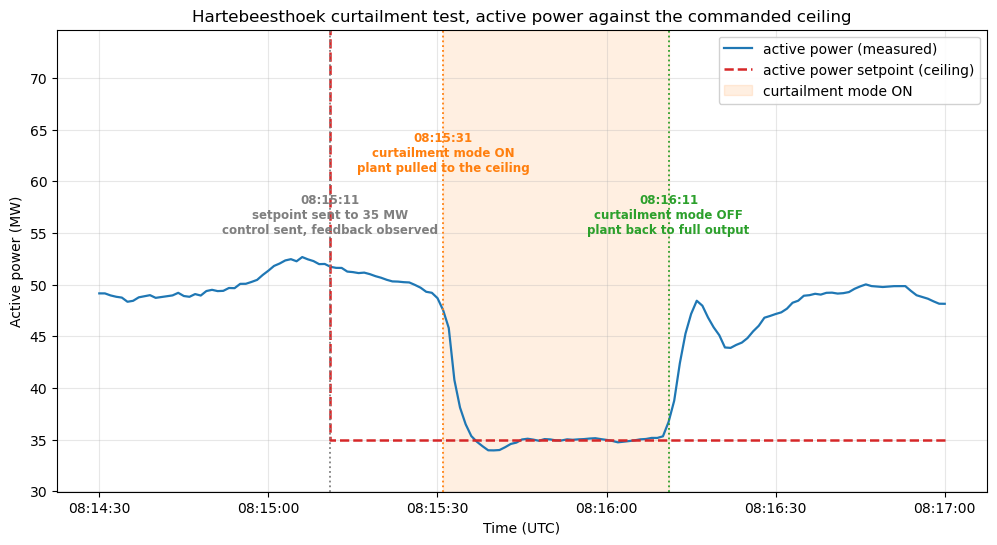

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

poc_col = resolve("poc_p", required=True)
sp_col = resolve("sp_p", required=True)
ap_col = resolve("ap_mode", required=True)

# Pick the window: use the configured one if present, otherwise auto-detect around the
# first moment curtailment mode switches on.
window = EVENT_WINDOWS.get("curtailment")
if window and all(window):
    win = df.loc[window[0]:window[1]]
    note = None
else:
    on_idx = df.index[df[ap_col]]
    if len(on_idx) == 0:
        raise ValueError(f"no curtailment event to plot: '{ap_col}' is never on in this data")
    pad = pd.Timedelta(minutes=2)
    win = df.loc[on_idx[0] - pad: on_idx[0] + pad]
    note = f"no window configured, auto-detected around first mode-on at {on_idx[0].time()}"

if win.empty:
    raise ValueError("the configured curtailment window contains no rows; check the dates")

ap = win[ap_col].astype(bool)
poc_p = win[poc_col]
sp_p = win[sp_col]

# Event 1: a genuine setpoint step, where the value actually changes from one sample to
# the next. The first sample is the window edge, not a step, so it is excluded. If the
# setpoint was already at its ceiling before the window opened there is no step, and
# sp_sent stays None rather than marking a false event at the window edge.
sp_mask = sp_p.ne(sp_p.shift())
if len(sp_mask):
    sp_mask.iloc[0] = False
sp_steps = sp_p.index[sp_mask]
sp_sent = sp_steps[0] if len(sp_steps) else None

# Events 2 and 3: curtailment mode turns on, then off. A window that opens already on
# counts its first sample as the on edge. Either edge may be absent in a partial capture.
ap_mask = ap.ne(ap.shift())
if len(ap_mask):
    ap_mask.iloc[0] = bool(ap.iloc[0])
on_edges = ap.index[ap & ap_mask]
mode_on = on_edges[0] if len(on_edges) else None
off_edges = ap.index[(~ap) & ap_mask & (ap.index > mode_on)] if mode_on is not None else []
mode_off = off_edges[0] if len(off_edges) else None

# The ceiling is whatever the setpoint holds while the plant is curtailed.
if mode_on is not None:
    ceiling = sp_p.loc[mode_on]
elif sp_sent is not None:
    ceiling = sp_p.loc[sp_sent]
else:
    ceiling = sp_p.iloc[-1]

# Recognise the case where the setpoint and the mode are switched on together, so there
# is no separate sent-but-inert phase. Treat them as effectively simultaneous within a
# few seconds and merge them into a single honest marker.
combined = (sp_sent is not None and mode_on is not None
            and abs(mode_on - sp_sent) <= pd.Timedelta(seconds=5))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(poc_p.index, poc_p, color="#1f77b4", lw=1.6, label="active power (measured)")
ax.plot(sp_p.index, sp_p, color="#d62728", lw=1.8, ls="--", drawstyle="steps-post",
        label="active power setpoint (ceiling)")
if mode_on is not None:
    span_end = mode_off if mode_off is not None else win.index[-1]
    ax.axvspan(mode_on, span_end, color="#ff7f0e", alpha=0.12, label="curtailment mode ON")

# Annotate only the events actually found, merging the pair when they coincide.
events = []
if combined:
    events.append((mode_on, "#ff7f0e",
                   f"{mode_on:%H:%M:%S}\nsetpoint sent to {ceiling:.0f} MW and mode ON together\nplant pulled to the ceiling"))
else:
    if sp_sent is not None:
        events.append((sp_sent, "#7f7f7f",
                       f"{sp_sent:%H:%M:%S}\nsetpoint sent to {ceiling:.0f} MW\ncontrol sent, feedback observed"))
    if mode_on is not None:
        events.append((mode_on, "#ff7f0e",
                       f"{mode_on:%H:%M:%S}\ncurtailment mode ON\nplant pulled to the ceiling"))
if mode_off is not None:
    events.append((mode_off, "#2ca02c",
                   f"{mode_off:%H:%M:%S}\ncurtailment mode OFF\nplant back to full output"))

ymax, ymin = poc_p.max(), poc_p.min()
for i, (ts, colour, text) in enumerate(events):
    ax.axvline(ts, color=colour, ls=":", lw=1.3)
    ax.annotate(text, xy=(ts, ymax), xytext=(ts, ymax + 2 + (i % 2) * 6),
                ha="center", va="bottom", fontsize=8.5, color=colour, fontweight="bold")

ax.set_ylim(ymin - 4, ymax + 22)
ax.set_xlabel(f"Time ({TIME_ZONE_LABEL})")
ax.set_ylabel("Active power (MW)")
ax.set_title(f"{SITE_NAME} curtailment test, active power against the commanded ceiling")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", framealpha=0.9)

out_path = OUTPUT_DIR / f"{SITE_SLUG}_curtailment.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")

# Build a short, honest narrative that adapts to whatever the capture contains, so the
# story still holds when a phase is missed, merged, or runs past the window edge.
story = []
if combined:
    story.append(f"The setpoint to {ceiling:.0f} MW and curtailment mode were switched on together "
                 f"at {mode_on:%H:%M:%S}, so there is no separate sent-but-inert phase to observe here.")
elif sp_sent is not None:
    story.append(f"The setpoint to {ceiling:.0f} MW was sent at {sp_sent:%H:%M:%S} while the mode was "
                 f"still off and the output kept running, so the command was received but inert.")
else:
    story.append("The setpoint was already at its ceiling before this window opened, so the moment it "
                 "was first sent is not captured here.")

if mode_on is not None:
    held = float(poc_p[ap].median())
    story.append(f"After mode ON at {mode_on:%H:%M:%S} the output settled near {held:.0f} MW against a "
                 f"{ceiling:.0f} MW ceiling, so the plant was curtailed to the ceiling.")
else:
    story.append("Curtailment mode never switches on in this window, so the curtail-to-ceiling check "
                 "cannot be observed here.")

if mode_off is not None:
    after = poc_p[poc_p.index > mode_off]
    if len(after):
        story.append(f"After mode OFF at {mode_off:%H:%M:%S} the output recovered to about "
                     f"{after.median():.0f} MW, so the plant returned to full output.")
    else:
        story.append(f"Mode OFF lands at {mode_off:%H:%M:%S}, at the very edge of the window, so the "
                     "recovery to full output is not captured here.")
elif mode_on is not None:
    story.append("The mode is still on at the end of this window, so the return to full output is not "
                 "captured here.")

if note:
    print(note)
print(f"Commanded ceiling: {ceiling:.0f} MW | figure saved to {out_path}")
print("\nFindings:")
for n, line in enumerate(story, start=1):
    print(f"  {n}. {line}")
plt.show()

### What the curtailment plot shows

The trace tells the three-step story cleanly. Before the constraint is applied the plant runs at around 50 MW, and at 08:15:11 the ceiling drops to 35 MW while curtailment mode is still off. The output does not move: the command has been received and echoed back, but it is inert, which is exactly the first check in the procedure [1]. Twenty seconds later, at 08:15:31, the mode is switched on and the output falls within a few seconds to sit on the 35 MW line and hold there. This is the heart of the test, because the plant respects the ceiling as a hard maximum rather than chasing it as a target. At 08:16:11 the mode is switched off and the output climbs back toward its earlier level near 48 MW. All three checks, the command received, the plant curtailed to the ceiling, and the plant released to full output, are satisfied in this single event.